# Emissions de CO₂ : scénarios courant vs déclarés

Comparaison des trajectoires d’émissions totales (toutes sources) en scénarios **courant** vs **stated policies** et lien avec la croissance des usages IA.


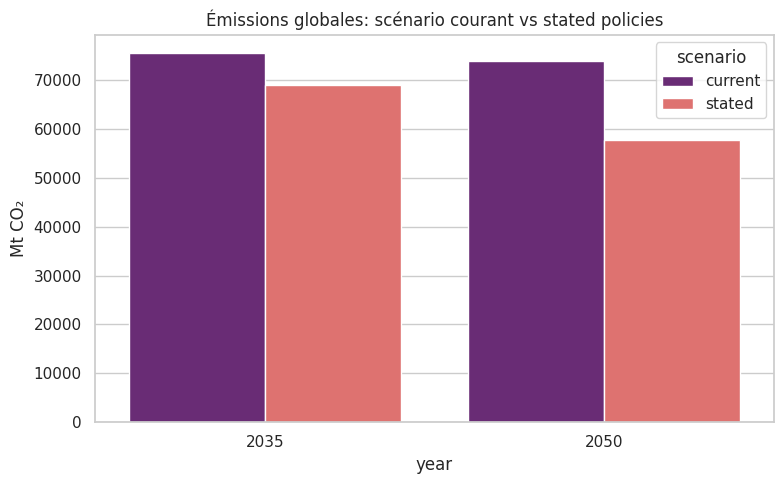

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (8, 5)

root = Path('../data/preproc')
df = pd.read_excel(root / 'total_co2_emissions.xlsx')

# Mise au format long
melt = df.melt(id_vars='Region', var_name='horizon', value_name='MtCO2')
# On sépare le nom du scénario
melt[['year', 'scenario']] = melt['horizon'].str.extract(r'(\d{4})_(.*)')

# Focus 2035/2050 et agrégation monde (somme si plusieurs régions)
focus = melt[melt['year'].isin(['2035', '2050'])]
global_totals = focus.groupby(['year', 'scenario'], as_index=False)['MtCO2'].sum()

ax = sns.barplot(data=global_totals, x='year', y='MtCO2', hue='scenario', palette='magma')
ax.set_title('Émissions globales: scénario courant vs stated policies')
ax.set_ylabel('Mt CO₂')
plt.tight_layout()
plt.show()


In [2]:
# Ratio simple: comparer l’ordre de grandeur des émissions aux besoins data centers
import pandas as pd
from pathlib import Path

root = Path('../data/preproc')
dc = pd.read_excel(root / 'data_center_electricity_demand_TWh.xlsx')
# Intensité carbone implicite pour donner un ordre de grandeur (hypothèse simplifiée 0.35 kg CO2/kWh)
INTENSITE = 0.35  # kg CO2 par kWh

est = dc[['Year', 'Total']].copy()
est['MtCO2_equiv'] = est['Total'] * 1e9 * INTENSITE / 1e6  # TWh -> kWh ; kg -> Mt
est.head()


,Year,Total,MtCO2_equiv
0,2023,530,185500.0
1,2024,599,209650.0
2,2025,682,238700.0
3,2026,783,274050.0
4,2027,910,318500.0


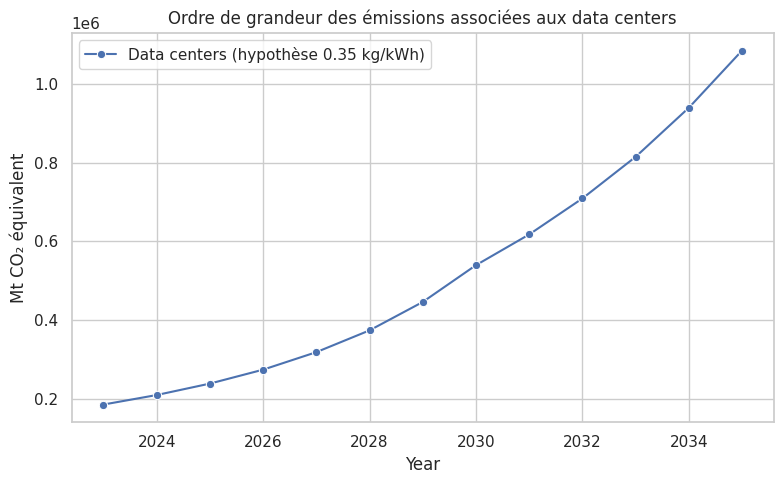

In [3]:
ax = sns.lineplot(data=est, x='Year', y='MtCO2_equiv', marker='o', label='Data centers (hypothèse 0.35 kg/kWh)')
ax.set_ylabel('Mt CO₂ équivalent')
ax.set_title('Ordre de grandeur des émissions associées aux data centers')
plt.tight_layout()
plt.show()


## Lecture rapide
- Les scénarios “current” sont nettement plus émissifs que les “stated policies” en 2035/2050 : l’écart illustre le besoin d’actions supplémentaires.
- Même avec une intensité carbone moyenne (0,35 kgCO₂/kWh), les data centers pourraient ajouter des centaines de MtCO₂ si le mix n’est pas fortement décarboné.
- Sans prédiction fine, cette comparaison souligne l’urgence d’une électricité décarbonée pour absorber l’IA.


## Analyse complémentaire : écarts, CAGRs, scénarios IA/crypto
- Écarts 2035/2050 vs current (Δ MtCO₂, %).
- CAGR de réduction 2024→2035/2050 par scénario.
- Estimation d’émissions associées aux data centers pour deux intensités carbone (0,35 et 0,1 kg/kWh).


In [4]:
# Écarts vs current
df_scen = melt[melt['year'].isin(['2035','2050'])].copy()
pivot = df_scen.pivot_table(index='year', columns='scenario', values='MtCO2', aggfunc='sum')
if 'current' in pivot.columns:
    for sc in pivot.columns:
        if sc=='current':
            continue
        for yr in pivot.index:
            base = pivot.loc[yr,'current']
            val = pivot.loc[yr, sc]
            print(f"{sc} {yr}: Δ={val-base:.1f} MtCO2, {val/base*100 if base else np.nan:.1f}% du current")


stated 2035: Δ=-6462.0 MtCO2, 91.4% du current
stated 2050: Δ=-16057.0 MtCO2, 78.2% du current


In [5]:
# CAGR 2024->2035/2050
cagr_rows=[]
base_year=2024
for sc in melt['scenario'].unique():
    sc_data = melt[melt['scenario']==sc]
    if base_year in sc_data['year'].astype(int).values:
        base = sc_data.loc[sc_data['year'].astype(int)==base_year,'MtCO2'].values[0]
        for target in [2035,2050]:
            if target in sc_data['year'].astype(int).values and base>0:
                val = sc_data.loc[sc_data['year'].astype(int)==target,'MtCO2'].values[0]
                yrs = target-base_year
                cagr_rows.append({'scenario':sc,'target':target,'CAGR':(val/base)**(1/yrs)-1})
pd.DataFrame(cagr_rows)


""


In [6]:
# Emissions estimées data centers (intensités 0.35 / 0.1)
INTS=[0.35,0.1]
co2_dc=[]
for _, r in dc.iterrows():
    for inten in INTS:
        co2_dc.append({'Year':r['Year'], 'Intensity':inten, 'MtCO2_equiv': r['Total']*1e9*inten/1e6})
pd.DataFrame(co2_dc)


,Year,Intensity,MtCO2_equiv
0,2023,0.35,185500.0
1,2023,0.10,53000.0
2,2024,0.35,209650.0
3,2024,0.10,59900.0
4,2025,0.35,238700.0
5,2025,0.10,68200.0
6,2026,0.35,274050.0
7,2026,0.10,78300.0
8,2027,0.35,318500.0
9,2027,0.10,91000.0
